# Laboratorio 5

## Integrantes

| Nombre                            | Carnet | Usuario Git |
| --------------------------------- | ------ | ----------- |
| Edwin Jose Gabriel De Leon Garcia | 22809  | EJGDLG      |
| Gustavo Adolfo Cruz Bardales      | 22779  | G2309       |
| Josué Emanuel Say Garcia          | 22801  | JosueSay    |
| Mathew Alexander Cordero Aquino   | 22982  | donmatthiuz |


## Repositorio

[Link al Repositorio](https://github.com/donmatthiuz/RL/tree/lab5)

## Caso

Una empresa de gestión de tráfico urbano está evaluando el uso de RL con aproximación de función para controlar semáforos en una intersección con flujo vehicular variable. El estado del sistema es continuo: incluye densidad de vehículos, velocidad promedio y tiempo de espera acumulado en cada carril. La empresa necesita entender si la aproximación lineal es suficiente para este dominio antes de invertir en una solución basada en redes neuronales profundas.

Su grupo ha sido contratado para implementar y comparar aproximación tabular contra aproximación lineal sobre el mismo entorno, analizar las limitaciones de cada enfoque, y producir un dictamen técnico que justifique o descarte el salto hacia Deep RL.

## Task 1

Respondan las siguientes preguntas con argumentación técnica rigurosa. No implementen nada:

### Inciso 1

Para el dominio de control de semáforos descrito, diseñen un vector de características $x(s) \in \mathbb{R}^d$ para aproximación lineal. Especifiquen cada componente $x_i(s)$, su rango de valores y la justificación de su inclusión. Argumenten si las características que eligieron son suficientes para capturar las relaciones relevantes entre el estado y el valor, o si existen interacciones entre características que la aproximación lineal no puede representar sin una extensión explícita del vector.

**Respuesta:**

La intersección tiene cuatro accesos con dos carriles cada uno, así que $\ell = 1,\dots,8$ recorre los carriles. Cada carril aporta sus tres mediciones y se agregan tres características globales:

$$
\mathbf{x}(s) = \big[\ \rho_1, v_1, w_1,\ \dots,\ \rho_8, v_8, w_8,\ \phi,\ \tau,\ 1\ \big]^{\top} \in \mathbb{R}^{27}
$$

Las tres mediciones se escalan a $[0,1]$ dividiendo entre su máximo, porque vienen en unidades distintas y sin escalar la de números más grandes domina la actualización de $\mathbf{w}$. La estimación es $\hat{V}(s,\mathbf{w}) = \mathbf{w}^{\top}\mathbf{x}(s)$, con gradiente $\nabla_{\mathbf{w}}\hat{V}(s,\mathbf{w}) = \mathbf{x}(s)$.

| Componente | Rango | Justificación |
| :--- | :--- | :--- |
| $\rho_\ell$ (densidad) | $[0,1]$ | Cuántos vehículos esperan en el carril. Es la característica principal: más vehículos retenidos en rojo, peor el valor. |
| $v_\ell$ (velocidad) | $[0,1]$ | Distingue un carril que va saliendo de uno detenido en cola. Su peso debería salir con signo contrario al de la densidad. |
| $w_\ell$ (espera) | $[0,1]$ | Cuánto llevan esperando, que la densidad sola no dice. Sin ella el agente favorece siempre al eje con más tráfico. |
| $\phi$ (fase) | $\{0,1\}$ | Cuál eje tiene el verde ($1$ = norte-sur). Sin ella las mismas colas son ambiguas. |
| $\tau$ (tiempo en fase) | $[0,1]$ | Cuánto lleva la fase actual. Cambiar cuesta tiempo, así que sirve para que el agente no cambie a cada rato. |
| $1$ (sesgo) | constante | Permite que la estimación no pase por cero. |

La aproximación lineal suma cada característica por separado con un peso fijo, y eso alcanza para lo básico: más densidad en rojo es peor valor, la espera penaliza cada vez más y la fase desplaza la estimación. No alcanza para las interacciones entre características, y aquí hay cuatro que importan:

- **Densidad alta con velocidad baja.** Lo grave es que ocurran juntas (carril trabado), y el modelo no distingue ese carril de dos carriles normales con los mismos valores.
- **Colas de los dos ejes.** Darle verde al norte-sur depende de su cola comparada con la del este-oeste, y sumarlas por separado no expresa esa comparación.
- **Saturación.** El costo de un vehículo más se dispara cuando la cola llena el carril, y ningún peso fijo produce ese umbral.
- **Fase con las colas.** El efecto de la densidad del norte debería cambiar de signo según $\phi$, pero $\phi$ entra sumando y solo corre la estimación.


Las cuatro interacciones son conocidas de antemano, así que conviene agregarlas al vector antes que saltar a una red neuronal:

| Característica añadida | Interacción que resuelve |
| :--- | :--- |
| $\rho_\ell \cdot (1 - v_\ell)$ por carril | Carril trabado |
| Indicador de $\rho_\ell$ sobre un umbral crítico | Saturación |
| Diferencia de presión entre norte-sur y este-oeste | Comparación entre ejes |
| Esa diferencia multiplicada por $\phi$ | Fase con las colas |

El vector llega a unas 45 características y sigue siendo lineal en $\mathbf{w}$, así que conserva la convergencia garantizada y la interpretabilidad. La aproximación lineal sirve como primera solución aquí si el vector incluye esas interacciones, y su desempeño es la línea base para comparar contra Deep RL.

### Inciso 2

Dado el vector de características que diseñaron, ¿cuántos parámetros tiene su aproximador lineal? Compárenlo con el tamaño de la tabla $Q$ que necesitaría un método tabular si discretizaran cada variable de estado en $10$ niveles. ¿Qué consecuencia tiene esa diferencia sobre la capacidad de generalización y sobre el riesgo de sobreajuste?

**Respuesta**

Supuestos:

- Se cuenta $\hat{Q}$, no $\hat{V}$. Como la comparación es contra una tabla $Q$, el aproximador también debe estimar valor-acción, replicando el vector por acción.
- El sesgo no se discretiza. La constante $1$ es un término del modelo lineal, no una variable del estado, así que no aporta factor.
- La fase aporta factor $2$, no $10$. $\phi$ ya es binaria y solo tiene dos valores posibles; forzarla a 10 niveles dejaría 8 niveles que nunca se visitan.


Con 27 características y 2 acciones el aproximador tiene $27 \times 2 = 54$ parámetros, o unos $90$ con el vector extendido del inciso anterior.

La tabla $Q$ necesita una entrada por par estado-acción. Son 25 variables continuas a 10 niveles (24 mediciones de carril más $\tau$), por la fase binaria y por las 2 acciones:

$$
|\mathcal{S}| \times |\mathcal{A}| = 10^{25} \times 2 \times 2 = 4 \times 10^{25}
$$

| Enfoque | Parámetros |
| :--- | :--- |
| Aproximador lineal | $54$ |
| Tabla $Q$ discretizada | $4 \times 10^{25}$ |

La diferencia es de unos 24 órdenes de magnitud. La tabla tiene más entradas que las visitas posibles en cualquier entrenamiento imaginable y no cabe en memoria, así que la comparación no es entre dos opciones viables.

La tabla no generaliza nada: cada entrada se aprende por separado, así que un estado nunca visitado no tiene valor estimado aunque su vecino sí. Con $10^{24}$ celdas y cualquier presupuesto realista de episodios, casi todas quedan sin visitar y la política es esencialmente aleatoria fuera del puñado de celdas vistas.

Los 54 pesos hacen lo contrario: cada actualización desde un estado mueve la estimación de todos los estados con características parecidas. Por eso el aproximador da un valor razonable para configuraciones de tráfico que nunca ocurrieron, que es justamente lo que se necesita en un espacio continuo.

Con 54 parámetros el riesgo de sobreajuste es bajo, y el problema real es el opuesto: **subajuste**, porque el modelo no puede representar las interacciones del inciso 1 por más datos que reciba. La tabla tampoco llega a sobreajustar en el sentido clásico: con una o dos visitas por celda, la mayoría se queda en su valor de inicialización y el problema es falta de cobertura antes que memorización de ruido.

La discretización agrega además un error propio: cortar la densidad en 10 niveles hace que estados distintos caigan en la misma celda y reciban el mismo valor. Ese error es de diseño y no baja con más episodios, solo con una malla más fina que multiplica todavía más el tamaño de la tabla.

### Inciso 3

La actualización semi-gradient TD(0) es

$$\mathbf{w}_{t+1} = \mathbf{w}_t + \alpha\,\delta_t\,\mathbf{x}(S_t), \qquad \delta_t = R_{t+1} + \gamma\,\hat v(S_{t+1},\mathbf{w}_t) - \hat v(S_t,\mathbf{w}_t)$$

con $\hat v(s,\mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)$. El objetivo natural para aproximación de función es el error de valor cuadrático medio

$$J(\mathbf{w}) = \overline{VE}(\mathbf{w}) = \sum_s \mu(s)\big[v_\pi(s) - \hat v(s,\mathbf{w})\big]^2$$

cuyo gradiente verdadero involucra derivar también el término $\gamma\hat v(S_{t+1},\mathbf{w})$ respecto a $\mathbf{w}$, porque ese término también depende de los pesos, semi-gradient TD no hace eso: trata $\gamma\hat v(S_{t+1},\mathbf{w})$ como si fuera una constante dentro de $\delta_t$ y solo diferencia la parte $-\hat v(S_t,\mathbf{w})$. 
Por construcción, la dirección de actualización $\delta_t\,\mathbf{x}(S_t)$ no es el gradiente de $J(\mathbf{w})$ para ningún objetivo fijo, así que no hay garantía de que el punto al que converge coincida con el mínimo de $J$.

El mínimo global de $J$ se alcanza en $\mathbf{w}^*$ tal que $\hat v_{\mathbf{w}^*} = \Pi v_\pi$, la proyección de mínimos cuadrados (ponderada por $\mu$) de la función de valor verdadera sobre el subespacio que el vector de características puede representar, TD en cambio, converge (con muestreo on-policy y tasa de aprendizaje decreciente) al punto fijo $\mathbf{w}_{TD}$ que resuelve

$$\hat v_{\mathbf{w}_{TD}} = \Pi\, T^\pi \hat v_{\mathbf{w}_{TD}}$$

donde $T^\pi$ es el operador de Bellman de $\pi$. $\mathbf{w}_{TD}$ es punto fijo del operador compuesto $\Pi T^\pi$, no de la proyección directa de $v_\pi$. $\Pi T^\pi$ es una contracción de módulo $\gamma$ bajo la norma ponderada por $\mu$, lo que garantiza que $\mathbf{w}_{TD}$ existe y es único, pero en general $\mathbf{w}_{TD} \neq \mathbf{w}^*$: TD converge, solo que a un punto distinto del que minimiza $J$.

La distancia entre ambos puntos está acotada:

$$\overline{VE}(\mathbf{w}_{TD}) \le \frac{1}{1-\gamma}\,\overline{VE}(\mathbf{w}^*)$$

Esta cota se degrada cuando $\gamma \to 1$: el factor $\frac{1}{1-\gamma}$ crece sin límite, así que el error del punto de TD puede ser arbitrariamente mayor que el mejor error alcanzable con el mismo vector de características. Con $\gamma$ pequeño el factor es cercano a $1$ y el punto de TD queda cerca del óptimo; con $\gamma$ cercano a $1$ el punto de TD puede quedar muy lejos de $\mathbf{w}^*$ aunque el vector de características represente bien a $v_\pi$.

**Condición sobre $\gamma$: el error en el punto de TD es más grave cuanto más cercano a $1$ esté $\gamma$.**

Para el dominio de semáforos esto genera una tensión real un $\gamma$ alto es deseable porque el efecto de una fase se propaga por varios ciclos (una cola que no se descarga ahora empeora el valor de los siguientes cambios de fase), así que un agente miope con $\gamma$ bajo aprendería a vaciar el carril visible sin anticipar el atasco que deja en el eje contrario, pero subir $\gamma$ amplifica exactamente la brecha entre $\mathbf{w}_{TD}$ y $\mathbf{w}^*$, y esa brecha se suma al error de representación que ya existe: el vector base del inciso 1 no captura todas las interacciones (colas de ambos ejes, saturación) sin las extensiones que se agregaron, así que $\overline{VE}(\mathbf{w}^*)$ ya es positivo antes de multiplicarlo por $\frac{1}{1-\gamma}$.

La elección razonable es un $\gamma$ moderado-alto (por ejemplo $0.9$–$0.95$) que cubra el horizonte de varios ciclos de semáforo sin acercarse a $\gamma \to 1$, apoyado en el vector extendido del inciso 1: incluir las interacciones (densidad-velocidad, diferencia de presión entre ejes) reduce $\overline{VE}(\mathbf{w}^*)$ y con eso el costo que la cota deja crecer con $\gamma$ resulta menor.

### Inciso 4



La tríada mortal son tres elementos que, combinados, pueden causar divergencia en el aprendizaje: aproximación de función, bootstrapping y aprendizaje off-policy, ningún par de los tres garantiza estabilidad por separado; el riesgo aparece cuando los tres están presentes a la vez (el contraejemplo de Baird es el caso canónico que lo ilustra con aproximación lineal).

En el dominio de semáforos:

- Aproximación de función: está forzada por el estado continuo (densidad, velocidad, espera): el inciso 2 ya mostró que una tabla es inviable, así que este componente no es evitable.
- Bootstrapping: también está forzado: el control de un semáforo es una tarea continua, sin episodios naturales, así que Monte Carlo (que necesita el retorno completo de un episodio) no aplica y TD es la opción práctica. El inciso 3 ya mostró que este bootstrapping introduce su propio costo de convergencia, agravado por el $\gamma$ alto que el dominio necesita.
- Aprendizaje off-policy: es el único de los tres que es una decisión de diseño, no una imposición del dominio. Si el grupo usa Q-learning para el control (la opción típica, porque aprende directamente la política óptima), el objetivo de bootstrapping usa $\max_a \hat q(S_{t+1},a,\mathbf{w})$ mientras el comportamiento explora con $\epsilon$-greedy eso es off-policy, si en cambio se usa SARSA o SARSA esperado, el aprendizaje es on-policy y ese tercer componente desaparece.

El componente más relevante es el aprendizaje off-policy, los otros dos son estructurales: el estado continuo obliga a aproximar y la naturaleza continua (no episódica) de la tarea obliga a bootstrapear, como esos dos ya están presentes por el dominio mismo, es el estatus on-policy u off-policy del algoritmo el que decide si se completa la tríada y aparece el riesgo de divergencia, es también la única variable que el grupo controla directamente al elegir el algoritmo (Q-learning vs. SARSA), así que ahí es donde la decisión de diseño tiene más impacto sobre la estabilidad.

Sobre el salto a Deep RL la tríada mortal no depende de si el aproximador es lineal o una red neuronal, depende de combinar aproximación + bootstrapping + off-policy. Cambiar a una red no elimina ninguno de los tres componentes, y las redes profundas sufren la misma inestabilidad (por eso DQN necesita target networks* y *experience replay, que son mecanismos para amortiguar exactamente este problema, no una prueba de que la tríada desaparece con Deep RL).

 Si el riesgo real es de convergencia, cambiar de aproximador no lo resuelve; lo que sí lo resuelve es la elección algorítmica: usar un método on-policy (SARSA, SARSA esperado) o una variante de gradiente verdadero (TDC, GTD2) en lugar de Q-learning con TD semi-gradient.

La justificación para Deep RL tendría que venir de otro lado: capacidad de representación, no estabilidad, los incisos 1 y 2 ya mostraron que el vector lineal extendido (unas 45 características, unos 90 parámetros con dos acciones) cubre las interacciones relevantes del dominio con bajo riesgo de sobreajuste, y no hay evidencia de que $v_\pi$ tenga estructura que ese vector no pueda capturar, por lo tanto, el salto a Deep RL no está teóricamente justificado en este dominio, el riesgo de la tríada se controla eligiendo un algoritmo on-policy, y la aproximación lineal (con las extensiones del inciso 1) es suficiente en capacidad de representación.

## Task 2

Implementen semi-gradiente TD con aproximación lineal sobre un entorno de intersección simplificado y
compárenlo con Q-Learning tabular de la semana anterior.


### Implementacion



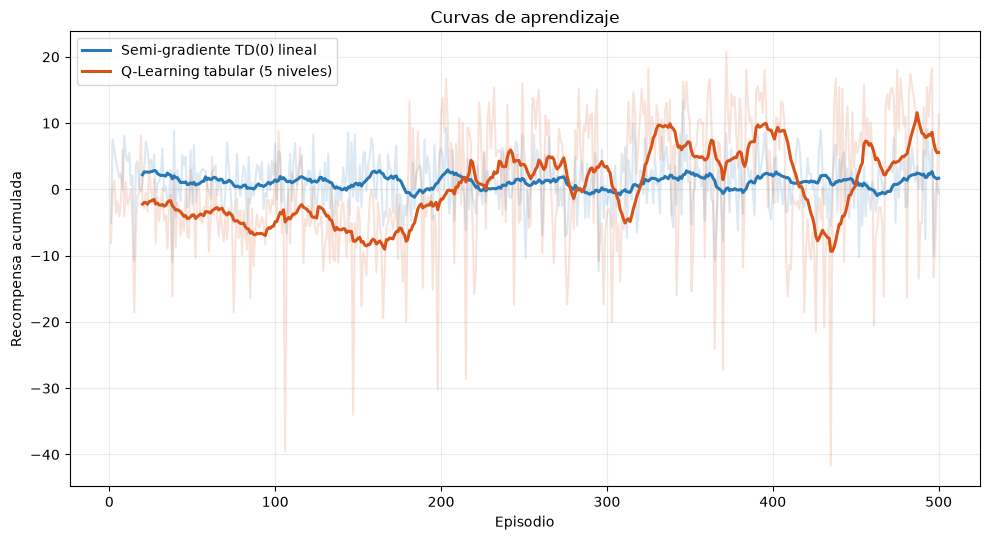

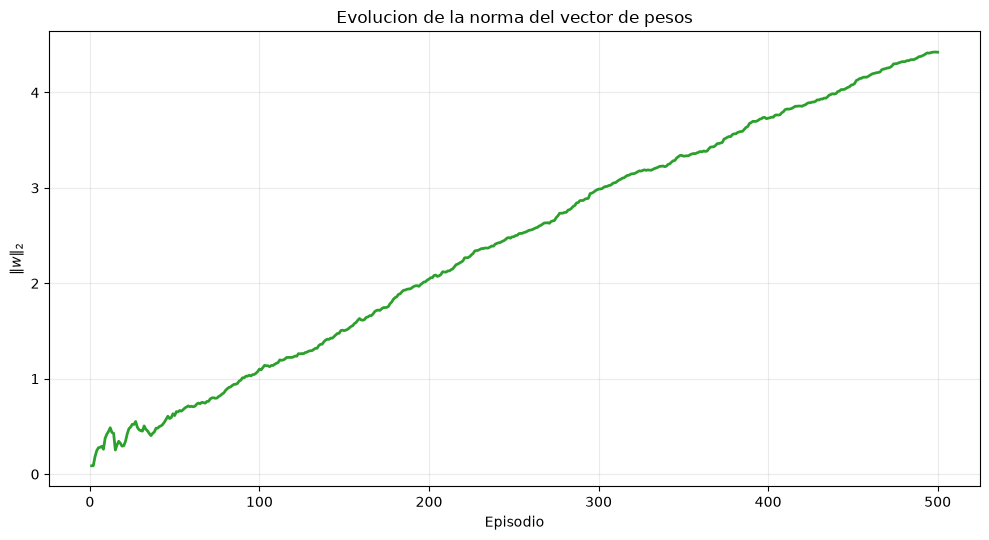

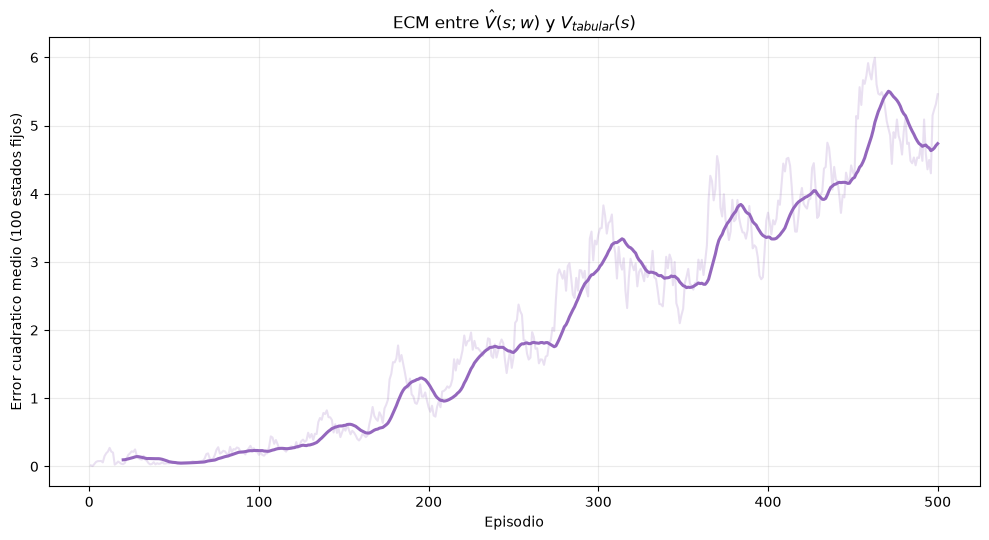


Resumen del entrenamiento
  Episodios: 500
  Recompensa TD, promedio ultimos 50: 0.956
  Recompensa Q-Learning, promedio ultimos 50: 5.942
  Norma final de w: 4.423
  ECM final sobre 100 estados: 5.459
  Graficas:
    - C:\Users\Staecy Cordero\Videos\RL\tarea2_td_qlearning\resultados\01_curvas_aprendizaje.png
    - C:\Users\Staecy Cordero\Videos\RL\tarea2_td_qlearning\resultados\02_norma_pesos.png
    - C:\Users\Staecy Cordero\Videos\RL\tarea2_td_qlearning\resultados\03_error_cuadratico_medio.png


In [1]:
from tarea2_td_qlearning.main import main

resultado = main(
    episodes=500,
    seed=42,
    show_plots=True
)

### Inciso 1

¿En qué fase del entrenamiento la aproximación lineal supera al método tabular en recompensa
acumulada? ¿A qué atribuyen ese comportamiento considerando las propiedades de generalización
de cada método?


### Inciso 2

¿La norma ∥ 𝑤 ∥converge o sigue creciendo al final del entrenamiento? ¿Qué indica ese
comportamiento sobre la estabilidad del algoritmo y sobre la adecuación del vector de características
diseñado?

